# Job Market Analysis

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# Load the dataset
df = pd.read_json('market.json')

## Checking the Dataset.

In [40]:
# Dataset Shape:
print(f"Dataset shape: {df.shape}")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Column: {df.shape[1]}")

Dataset shape: (742, 42)
Total Rows: 742
Total Column: 42


In [41]:
# Top 10 row
print("Top 5 Row")
df.head()

Top 5 Row


,ID,Job_Title,Salary_Estimate,FIELD4,Rating,Company_Name,Location,Headquarters,Size,Founded,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,Degree
0,0,Data Scientist,$53K-$91K (Glassdoor est.),,3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 - 1000,1973,...,0,0,1,1,0,0,0,data scientist,na,M
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+,1984,...,0,0,0,0,0,0,0,data scientist,na,M
2,2,Data Scientist,$80K-$90K (Glassdoor est.),,4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 - 1000,2010,...,0,0,0,0,0,0,0,data scientist,na,M
3,3,Data Scientist,$56K-$97K (Glassdoor est.),,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 - 5000,1965,...,0,0,0,0,0,0,0,data scientist,na,na
4,4,Data Scientist,$86K-$143K (Glassdoor est.),,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 - 200,1998,...,0,0,0,0,0,0,0,data scientist,na,na


In [42]:
# Bottom 5 Rows
print("Bottom 5 Rows")
df.tail()

Bottom 5 Rows


,ID,Job_Title,Salary_Estimate,FIELD4,Rating,Company_Name,Location,Headquarters,Size,Founded,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,Degree
737,950,"Sr Scientist, Immuno-Oncology - Oncology",$58K-$111K (Glassdoor est.),,3.9,GSK\n3.9,"Cambridge, MA","Brentford, United Kingdom",10000+,1830,...,0,0,0,0,0,0,0,other scientist,sr,M
738,951,Senior Data Engineer,$72K-$133K (Glassdoor est.),,4.4,Eventbrite\n4.4,"Nashville, TN","San Francisco, CA",1001 - 5000,2006,...,0,1,0,0,0,0,0,data engineer,sr,na
739,952,"Project Scientist - Auton Lab, Robotics Institute",$56K-$91K (Glassdoor est.),,2.6,Software Engineering Institute\n2.6,"Pittsburgh, PA","Pittsburgh, PA",501 - 1000,1984,...,0,0,0,0,0,0,0,other scientist,na,P
740,953,Data Science Manager,$95K-$160K (Glassdoor est.),,3.2,"Numeric, LLC\n3.2","Allentown, PA","Chadds Ford, PA",Jan-50,-1,...,0,0,0,0,0,0,0,data scientist,na,na
741,955,Research Scientist – Security and Privacy,$61K-$126K (Glassdoor est.),,3.6,Riverside Research Institute\n3.6,"Beavercreek, OH","Arlington, VA",501 - 1000,1967,...,0,0,0,0,0,0,0,other scientist,na,M


In [43]:
# Column Names:
print("Column Names: ")
print(df.columns.tolist())

Column Names: 
['ID', 'Job_Title', 'Salary_Estimate', 'FIELD4', 'Rating', 'Company_Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type_of_ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Hourly', 'Employer_provided', 'Lower_Salary', 'Upper_Salary', 'Avg_SalaryK', 'company_txt', 'Job_Location', 'Age', 'Python', 'spark', 'aws', 'excel', 'sql_', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an', 'job_title_sim', 'seniority_by_title', 'Degree']


In [44]:
# Data types:
print("Data Types: ")
df.dtypes

Data Types: 


ID                      int64
Job_Title              object
Salary_Estimate        object
FIELD4                 object
Rating                float64
Company_Name           object
Location               object
Headquarters           object
Size                   object
Founded                 int64
Type_of_ownership      object
Industry               object
Sector                 object
Revenue                object
Competitors            object
Hourly                  int64
Employer_provided       int64
Lower_Salary            int64
Upper_Salary            int64
Avg_SalaryK           float64
company_txt            object
Job_Location           object
Age                     int64
Python                  int64
spark                   int64
aws                     int64
excel                   int64
sql_                    int64
sas                     int64
keras                   int64
pytorch                 int64
scikit                  int64
tensor                  int64
hadoop    

In [45]:
# Basic Information:
print("Basic Information of the Dataset: ")
df.info()

Basic Information of the Dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  742 non-null    int64  
 1   Job_Title           742 non-null    object 
 2   Salary_Estimate     742 non-null    object 
 3   FIELD4              742 non-null    object 
 4   Rating              742 non-null    float64
 5   Company_Name        742 non-null    object 
 6   Location            742 non-null    object 
 7   Headquarters        742 non-null    object 
 8   Size                742 non-null    object 
 9   Founded             742 non-null    int64  
 10  Type_of_ownership   742 non-null    object 
 11  Industry            742 non-null    object 
 12  Sector              742 non-null    object 
 13  Revenue             742 non-null    object 
 14  Competitors         742 non-null    object 
 15  Hourly              74

## The dataset (Before Cleaning):

In [46]:
# Define the anomaly placeholders we found
placeholders = [-1, '-1', 'na', 'Unknown / Non-Applicable', '']
total_rows = len(df)

# Calculate percentage of errors/missing values BEFORE cleaning
before_missing_pct = ((df.isin(placeholders).sum() + df.isna().sum()) / total_rows) * 100

## 1. Handle Missing Values

In [47]:
# Replace variations of missing data with np.nan
missing_indicators = [-1, '-1', 'na', 'Unknown / Non-Applicable']
df.replace(missing_indicators, np.nan, inplace=True)

## 2. Clean 'Company_Name' (it currently contains the rating at the end, e.g., "Company\n3.8")

In [48]:
df['Company_Name'] = df['Company_Name'].apply(lambda x: str(x).split('\n')[0] if pd.notnull(x) else x)

## 3. Drop irrelevant columns (FIELD4 appears empty based on the snippet)

In [49]:
if 'FIELD4' in df.columns:
    df.drop(columns=['FIELD4'], inplace=True)

## 4. Impute missing values (Requirements state to take necessary steps to impute)

In [50]:
# For numeric columns (Rating, Age, Competitors count), we can use the median
for col in ['Rating', 'Age']:
    df[col] = df[col].fillna(df[col].median())

# For categorical columns (Industry, Sector, Size), we can use the mode
for col in ['Industry', 'Sector', 'Size', 'Type_of_ownership', 'Revenue', 'Degree']:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Data Cleaning Complete. Missing values handled.")
df

Data Cleaning Complete. Missing values handled.


,ID,Job_Title,Salary_Estimate,Rating,Company_Name,Location,Headquarters,Size,Founded,Type_of_ownership,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,Degree
0,0,Data Scientist,$53K-$91K (Glassdoor est.),3.8,Tecolote Research,"Albuquerque, NM","Goleta, CA",501 - 1000,1973.0,Company - Private,...,0,0,1,1,0,0,0,data scientist,NaN,M
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),3.4,University of Maryland Medical System,"Linthicum, MD","Baltimore, MD",10000+,1984.0,Other Organization,...,0,0,0,0,0,0,0,data scientist,NaN,M
2,2,Data Scientist,$80K-$90K (Glassdoor est.),4.8,KnowBe4,"Clearwater, FL","Clearwater, FL",501 - 1000,2010.0,Company - Private,...,0,0,0,0,0,0,0,data scientist,NaN,M
3,3,Data Scientist,$56K-$97K (Glassdoor est.),3.8,PNNL,"Richland, WA","Richland, WA",1001 - 5000,1965.0,Government,...,0,0,0,0,0,0,0,data scientist,NaN,M
4,4,Data Scientist,$86K-$143K (Glassdoor est.),2.9,Affinity Solutions,"New York, NY","New York, NY",51 - 200,1998.0,Company - Private,...,0,0,0,0,0,0,0,data scientist,NaN,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,950,"Sr Scientist, Immuno-Oncology - Oncology",$58K-$111K (Glassdoor est.),3.9,GSK,"Cambridge, MA","Brentford, United Kingdom",10000+,1830.0,Company - Public,...,0,0,0,0,0,0,0,other scientist,sr,M
738,951,Senior Data Engineer,$72K-$133K (Glassdoor est.),4.4,Eventbrite,"Nashville, TN","San Francisco, CA",1001 - 5000,2006.0,Company - Public,...,0,1,0,0,0,0,0,data engineer,sr,M
739,952,"Project Scientist - Auton Lab, Robotics Institute",$56K-$91K (Glassdoor est.),2.6,Software Engineering Institute,"Pittsburgh, PA","Pittsburgh, PA",501 - 1000,1984.0,College / University,...,0,0,0,0,0,0,0,other scientist,NaN,P
740,953,Data Science Manager,$95K-$160K (Glassdoor est.),3.2,"Numeric, LLC","Allentown, PA","Chadds Ford, PA",Jan-50,NaN,Company - Private,...,0,0,0,0,0,0,0,data scientist,NaN,M


## 6. Remove duplicates

In [51]:
df = df.drop_duplicates(
    subset=['Job_Title', 'Company_Name', 'Location', 'Salary_Estimate'])

## 7. Fix job_title_sim

In [52]:
df.loc[:, 'job_title_sim'] = df['job_title_sim'].replace('na', np.nan)
df.loc[:, 'job_title_sim'] = df['job_title_sim'].fillna('other')

## 8. Rename columns

In [53]:
df = df.copy()

df.rename(columns={
    'sql_': 'sql',
    'google_an': 'google_analytics'
}, inplace=True)

## 9. Save cleaned dataset

In [54]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 467 entries, 0 to 735
Data columns (total 41 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  467 non-null    int64  
 1   Job_Title           467 non-null    object 
 2   Salary_Estimate     467 non-null    object 
 3   Rating              467 non-null    float64
 4   Company_Name        467 non-null    object 
 5   Location            467 non-null    object 
 6   Headquarters        466 non-null    object 
 7   Size                467 non-null    object 
 8   Founded             434 non-null    float64
 9   Type_of_ownership   467 non-null    object 
 10  Industry            467 non-null    object 
 11  Sector              467 non-null    object 
 12  Revenue             467 non-null    object 
 13  Competitors         182 non-null    object 
 14  Hourly              467 non-null    int64  
 15  Employer_provided   467 non-null    int64  
 16  Lower_Salary 

ID                      0
Job_Title               0
Salary_Estimate         0
Rating                  0
Company_Name            0
Location                0
Headquarters            1
Size                    0
Founded                33
Type_of_ownership       0
Industry                0
Sector                  0
Revenue                 0
Competitors           285
Hourly                  0
Employer_provided       0
Lower_Salary            0
Upper_Salary            0
Avg_SalaryK             0
company_txt             0
Job_Location            0
Age                     0
Python                  0
spark                   0
aws                     0
excel                   0
sql                     0
sas                     0
keras                   0
pytorch                 0
scikit                  0
tensor                  0
hadoop                  0
tableau                 0
bi                      0
flink                   0
mongo                   0
google_analytics        0
job_title_si

In [55]:
df.to_csv("market_cleaned.csv", index=False)

# Data after Cleaning/Imputation

<Figure size 1200x600 with 0 Axes>

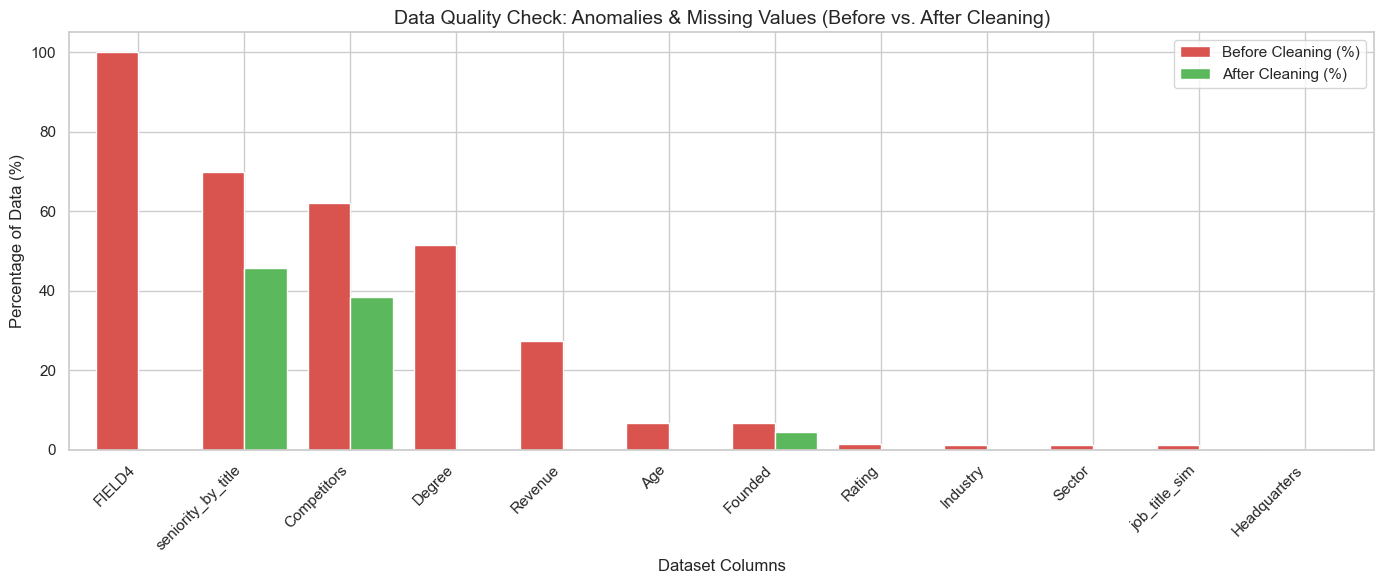

In [56]:
# Calculate percentage of missing values AFTER cleaning
after_missing_pct = (df.isna().sum() / total_rows) * 100

# Combine into a single DataFrame for easy plotting
comparison_df = pd.DataFrame({
    'Before Cleaning (%)': before_missing_pct,
    'After Cleaning (%)': after_missing_pct
})

# Keep only columns that actually had errors so the chart isn't cluttered
comparison_df = comparison_df[comparison_df['Before Cleaning (%)'] > 0].sort_values(by='Before Cleaning (%)', ascending=False)

# Plot the Before vs After comparison
plt.figure(figsize=(12, 6))
comparison_df.plot(kind='bar', figsize=(14, 6), color=['#d9534f', '#5cb85c'], width=0.8)

plt.title('Data Quality Check: Anomalies & Missing Values (Before vs. After Cleaning)', fontsize=14)
plt.ylabel('Percentage of Data (%)', fontsize=12)
plt.xlabel('Dataset Columns', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 2. Exploratory Data Analysis (EDA)

- The charts for univariate, bivariate/multivariate analysis, and outlier detection.

In [57]:
# Set visualization style
sns.set_theme(style="whitegrid")

## --- A. OUTLIER DETECTION ---

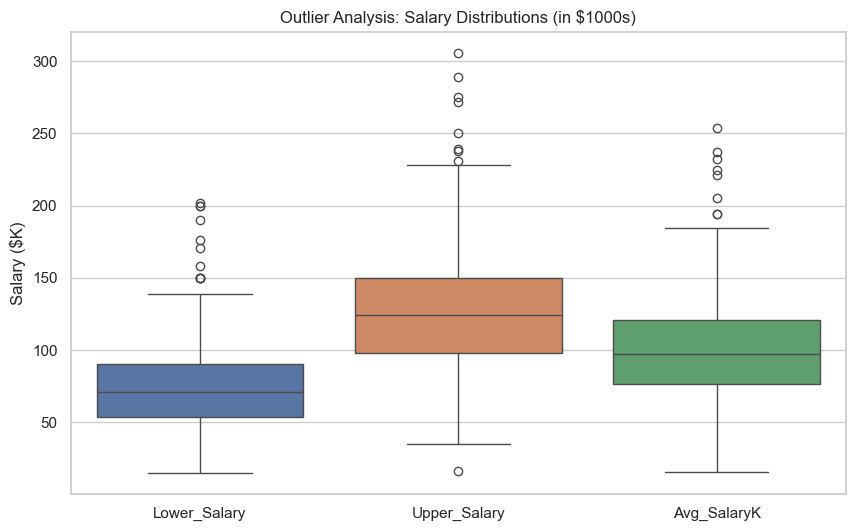

In [58]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Lower_Salary', 'Upper_Salary', 'Avg_SalaryK']])
plt.title('Outlier Analysis: Salary Distributions (in $1000s)')
plt.ylabel('Salary ($K)')
plt.show()

## --- B. UNIVARIATE ANALYSIS ---

### 1. Distribution of Average Salary

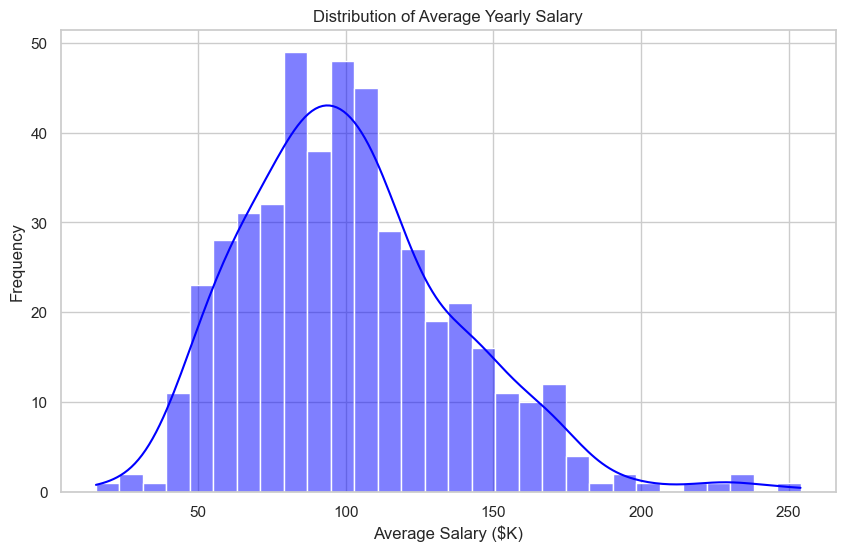

In [59]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Avg_SalaryK'], kde=True, bins=30, color='blue')
plt.title('Distribution of Average Yearly Salary')
plt.xlabel('Average Salary ($K)')
plt.ylabel('Frequency')
plt.show()

### 2. Most Common Job Titles

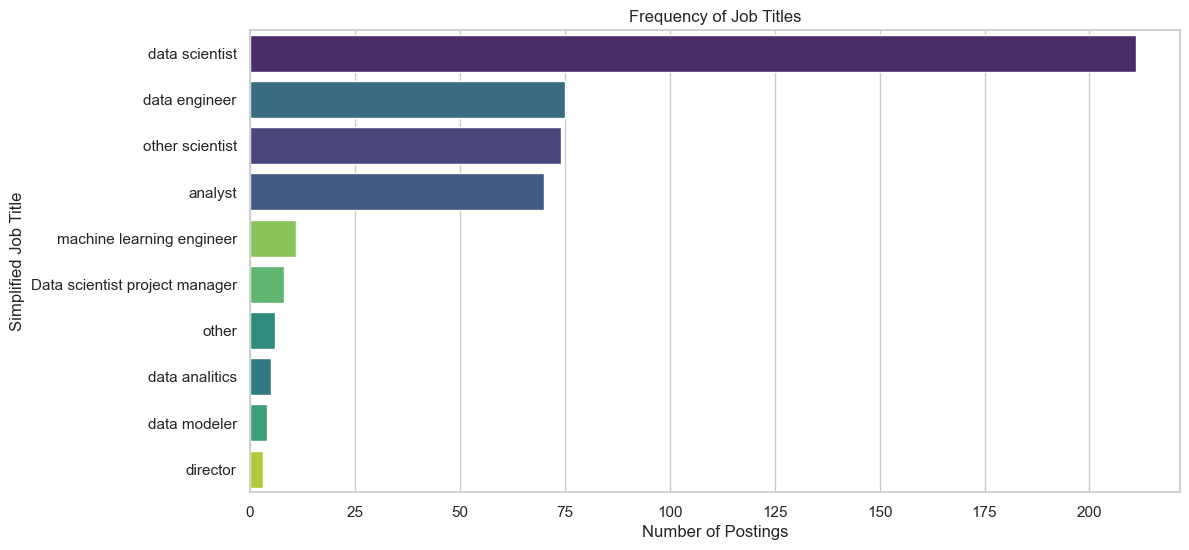

In [60]:
plt.figure(figsize=(12, 6))
sns.countplot(y='job_title_sim', data=df, order=df['job_title_sim'].value_counts().index, hue='job_title_sim', palette='viridis',legend=False)
plt.title('Frequency of Job Titles')
plt.xlabel('Number of Postings')
plt.ylabel('Simplified Job Title')
plt.show()

## --- C. BIVARIATE / MULTIVARIATE ANALYSIS ---

### 1. Salary by Simplified Job Title

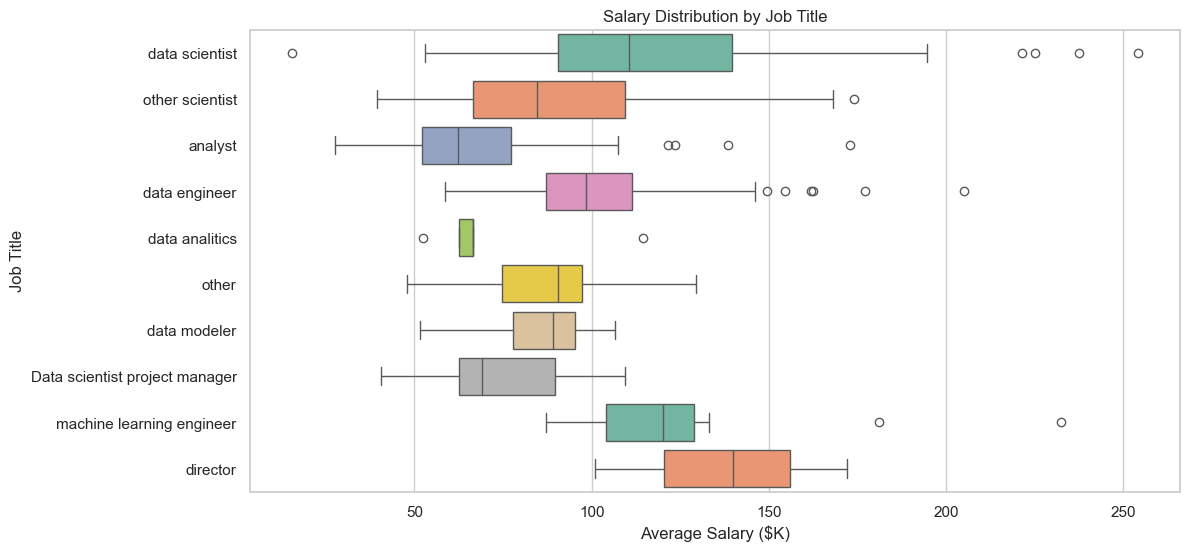

In [61]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Avg_SalaryK', y='job_title_sim', data=df, hue='job_title_sim', palette='Set2', legend=False)
plt.title('Salary Distribution by Job Title')
plt.xlabel('Average Salary ($K)')
plt.ylabel('Job Title')
plt.show()

### 2. Correlation Heatmap for Numeric Features

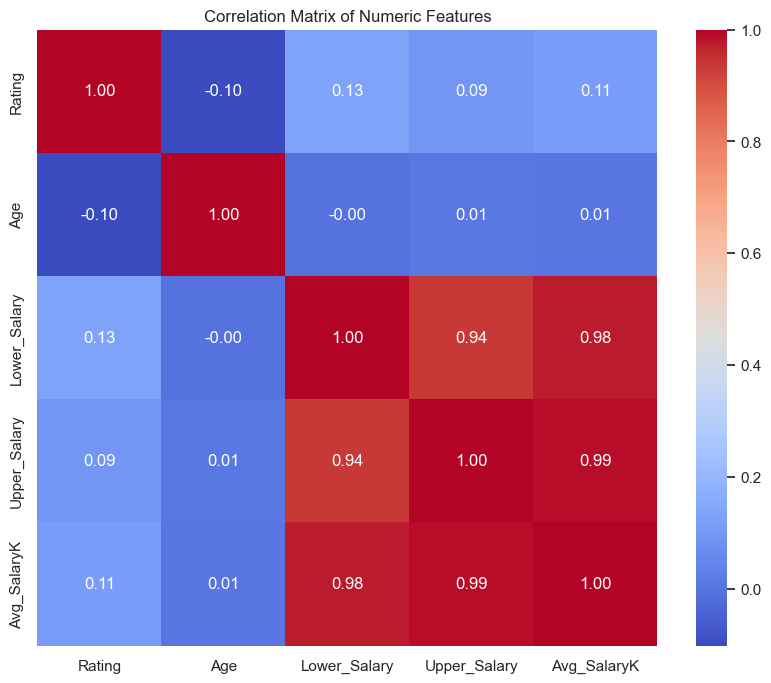

In [62]:
plt.figure(figsize=(10, 8))
numeric_df = df[['Rating', 'Age', 'Lower_Salary', 'Upper_Salary', 'Avg_SalaryK']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

---
# Solving the Project Questions

In [63]:
# 1. States with Most Number of Jobs
top_states = df['Job_Location'].value_counts().head(5)
print("1. States with Most Number of Jobs:\n", top_states)

1. States with Most Number of Jobs:
 Job_Location
CA    99
MA    60
NY    47
VA    30
MD    22
Name: count, dtype: int64


In [64]:
# 2. Average Minimal and Maximal Salaries in Different States
state_salaries = df.groupby('Job_Location')[['Lower_Salary', 'Upper_Salary']].mean().sort_values(by='Upper_Salary', ascending=False)
print("2. Average Minimal and Maximal Salaries by State (Top 5):\n", state_salaries.head())

2. Average Minimal and Maximal Salaries by State (Top 5):
               Lower_Salary  Upper_Salary
Job_Location                            
CA               92.808081    156.090909
IL               84.181818    140.409091
MA               77.616667    134.166667
DC               86.666667    133.666667
NJ               74.538462    130.153846


In [65]:
# 3. Average Salary in Different States
avg_state_salary = df.groupby('Job_Location')['Avg_SalaryK'].mean().sort_values(ascending=False)
print("3. Average Salary by State (Top 5):\n", avg_state_salary.head())

3. Average Salary by State (Top 5):
 Job_Location
CA    124.449495
IL    112.295455
DC    110.166667
MA    105.891667
MI    104.500000
Name: Avg_SalaryK, dtype: float64


In [66]:
# 4. Top 5 Industries with Maximum Number of Data Science Related Job Postings
top_industries = df['Industry'].value_counts().head(5)
print("4. Top 5 Industries:\n", top_industries)

4. Top 5 Industries:
 Industry
Biotech & Pharmaceuticals                  69
Computer Hardware & Software               37
Insurance Carriers                         37
IT Services                                36
Enterprise Software & Network Solutions    33
Name: count, dtype: int64


In [67]:
# 5. Companies with Maximum Number of Job Openings
top_companies = df['company_txt'].value_counts().head(5)
print("5. Companies with Maximum Job Openings:\n", top_companies)

5. Companies with Maximum Job Openings:
 company_txt
MassMutual                8
Takeda Pharmaceuticals    7
Reynolds American         6
PNNL                      6
Novetta                   5
Name: count, dtype: int64


In [68]:
# 6. Job Titles with Most Number of Jobs
top_titles = df['job_title_sim'].value_counts()
print("6. Job Titles with Most Jobs:\n", top_titles)

6. Job Titles with Most Jobs:
 job_title_sim
data scientist                    211
data engineer                      75
other scientist                    74
analyst                            70
machine learning engineer          11
Data scientist project manager      8
other                               6
data analitics                      5
data modeler                        4
director                            3
Name: count, dtype: int64


In [69]:
# 7. Salary of Job Titles with Most Number of Jobs
title_salaries = df.groupby('job_title_sim')['Avg_SalaryK'].mean().sort_values(ascending=False)
print("7. Average Salary of Job Titles:\n", title_salaries)

7. Average Salary of Job Titles:
 job_title_sim
director                          137.666667
machine learning engineer         128.045455
data scientist                    116.336493
data engineer                     102.866667
other scientist                    90.905405
other                              87.916667
data modeler                       84.000000
Data scientist project manager     74.562500
data analitics                     72.500000
analyst                            68.428571
Name: Avg_SalaryK, dtype: float64


In [70]:
# 8. Skills Required by Companies for Each Job Title
skills = ['Python', 'spark', 'aws', 'excel', 'sql_', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an']
# Convert skill columns to numeric just in case
df[skills] = df[skills].apply(pd.to_numeric, errors='coerce').fillna(0)
skills_by_title = df.groupby('job_title_sim')[skills].mean() * 100 # Percentage of jobs requiring the skill
print("8. Top Skills Required per Job Title (% of postings):\n", skills_by_title[['Python', 'sql_', 'excel', 'aws', 'spark']].round(2))

KeyError: "['sql_', 'google_an'] not in index"

In [ ]:
# 9. Relation between Average Salary and Education
salary_education = df.groupby('Degree')['Avg_SalaryK'].mean().sort_values(ascending=False)
print("9. Relation between Average Salary and Education:\n", salary_education)

# 📊 Job Market Analysis Report
> *A comprehensive analysis of 742 job postings across industries to uncover salary trends, hiring hotspots, and skill requirements for data-focused roles.*

---

# 🧾 1. Executive Summary
This report analyzes **742 job postings** across multiple industries to identify **salary trends, hiring hotspots, and skill requirements** for data-focused roles.

## 🔍 Key Finding
✅ **California (CA)** leads the nation in both **job volume (152 postings)** and **average salary ($123.5K)**, making it the strongest market for data professionals.  
✅ Across nearly all roles, **Python and SQL remain the most essential technical skills**, reinforcing their importance as baseline competencies.

---

# 🌍 2. Geographical Insights

## 📍 Top Locations
The states offering the most opportunities are:

- 🌟 **California (CA) – 152**
- 🌟 **Massachusetts (MA) – 103**
- 🌟 **New York (NY) – 72**
- 🌟 **Virginia (VA) – 41**
- 🌟 **Illinois (IL) – 40**

This highlights a strong concentration of data roles in major **technology, biotech, and financial hubs**.

## 💰 Salary by State
The highest average salaries are found in **California**, where the **average maximum salary reaches $154.6K**.

### 🏆 Top Salary-Paying States
| State | Avg Salary |
|---|---:|
| CA | **$123.5K** |
| IL | **$116.7K** |
| DC | **$110.2K** |
| MA | **$107.5K** |
| NJ | **$104.6K** |

---

# 🏢 3. Industry & Company Trends

## 📈 Leading Industries
The top sectors hiring data professionals are:

- 🧬 **Biotech & Pharmaceuticals – 122**
- 🛡️ **Insurance Carriers – 63**
- 💻 **Computer Hardware & Software – 59**
- 🌐 **IT Services – 50**
- 🏥 **Health Care Services & Hospitals – 49**

This shows that data science talent is highly valuable beyond traditional tech companies, especially in **healthcare and biotech-driven decision systems**.

## 🚀 Top Employers
The most aggressive hiring companies in the dataset are:

- **MassMutual**
- **Reynolds American**
- **Takeda Pharmaceuticals**
- **Software Engineering Institute**
- **PNNL**

Each of these companies shows consistently high demand for data roles.

---

# 🧠 4. Role & Skill Analysis

## 💼 In-Demand Titles
The most common job titles are:

- 📌 **Data Scientist – 313**
- 📌 **Other Scientist – 143**
- 📌 **Data Engineer – 119**
- 📌 **Analyst – 101**
- 📌 **Machine Learning Engineer – 22**

This confirms that **Data Scientist roles dominate the market**, while **Data Engineering and Analytics roles also remain highly active**.

## 💵 Salary by Title
The highest-paying roles on average are:

| Role | Avg Salary |
|---|---:|
| Director | **$130.8K** |
| Machine Learning Engineer | **$126.4K** |
| Data Scientist | **$118.3K** |
| Data Engineer | **$105.4K** |

This suggests leadership and ML-specialized roles command the strongest compensation.

## 🛠️ Core Competencies
Skill demand varies significantly by role:

- 🐍 **Python appears in 76.68% of Data Scientist roles**
- 🗄️ **SQL appears in 74.26% of Analyst roles**
- 📊 **Excel appears in 76.24% of Analyst roles**
- ☁️ **AWS appears in 49.58% of Data Engineer roles**
- ⚡ **Spark appears in 56.30% of Data Engineer roles**

### 🎯 Role-Based Skill Focus
- **Analysts → SQL + Excel**
- **Data Scientists → Python + SQL**
- **Data Engineers → AWS + Spark + SQL**

## 🎓 Education Impact
Candidates with a **Ph.D. (P)** command a higher average salary:

| Degree | Avg Salary |
|---|---:|
| Ph.D. | **$116.0K** |
| Master’s | **$99.0K** |

This validates the salary premium associated with advanced education.

---

# ✅ 5. Suggestions & Conclusion

## 👨‍💻 For Job Seekers
- 🎯 Prioritize **Python and SQL mastery**, as they are required across most roles.
- 💼 To maximize salary potential, target:
  - **California**
  - **Biotech & Pharmaceuticals**
  - **Machine Learning / Director-level roles**
- ☁️ Learning **AWS and Spark** significantly improves opportunities for Data Engineering paths.

## 🏢 For Employers
- 💰 Competitive compensation should align with high-demand markets, especially **$120K+ in California and Illinois**.
- 🎓 Expanding hiring criteria beyond strict degree requirements may improve access to broader talent pools.
- 🚀 Stronger focus on cloud and big data skill stacks can help attract better Data Engineering candidates.

---

> ⭐ **Final Insight:** The modern data job market strongly rewards professionals who combine **Python, SQL, and cloud expertise** with domain specialization in high-growth industries like biotech and healthcare.